In [1]:
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from taurex.cache import CIACache, OpacityCache

OpacityCache().set_opacity_path("/path/to/xsec")
CIACache().set_cia_path("/path/to/cia")

In [ ]:
from freckll.taurex import FreckllChemistryInput

chemistry = FreckllChemistryInput(
    network="venot-methanol-2020",
    photochemistry="auto",
    star_method="from-star",
    star_arg="hd209458",
    solve_method="rosenbrock",
    t_span=(0.0, 1e10),
    max_iter=100,
    nevals=200,
    dn_crit=1e-3,
    dndt_crit=1e-6,
    kzz=1e10,
    max_solve_time_hour=1,
    enable_diffusion=True,
    rtol=1e-2,
    atol=1e-15,
)

freckll.freckll.venot.io - INFO - Mapping decompo_rev to decomposition reactions
freckll.freckll.venot.io - INFO - Mapping combinaison_k0_kinf_rev_SRI to k0 reactions
freckll.freckll.venot.io - INFO - Mapping decompo_k0_kinf_rev to k0 reactions
freckll.freckll.venot.io - INFO - Mapping reaction_sansM_k0_kinf_rev to k0 reactions
freckll.freckll.venot.io - INFO - Mapping decompo_k0_kinf_rev_SRI to k0 reactions
freckll.freckll.venot.io - INFO - Mapping decompo_rev_plog to plog reactions
freckll.freckll.venot.io - INFO - Mapping combinaison_k0_kinf_rev to k0 reactions
freckll.freckll.venot.io - INFO - Mapping decompo_k0_rev to k0 reactions
freckll.freckll.venot.io - INFO - Mapping desexcitation_rev to de-excitation reactions
freckll.freckll.venot.io - INFO - Mapping combinaison_k0_rev to k0 reactions
freckll.freckll.venot.io - INFO - Mapping reaction_2_Corps_irrev to corps reactions
freckll.freckll.venot.io - INFO - Mapping reaction_2_Corps_rev to corps reactions
freckll.freckll.venot.io -

In [16]:
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.model import TransmissionModel
from taurex.planet import Planet
from taurex.stellar import BlackbodyStar
from taurex.temperature import Isothermal

isothermal = Isothermal(T=1500.0)


tm_cpu = TransmissionModel(
    planet=Planet(planet_radius=1, planet_mass=1),
    temperature_profile=isothermal,
    chemistry=chemistry,
    star=BlackbodyStar(temperature=5700.0, radius=1.0),
    atm_min_pressure=1e-5,
    atm_max_pressure=1e6,
    nlayers=100,
)
tm_cpu.add_contribution(AbsorptionContribution())
tm_cpu.add_contribution(CIAContribution(cia_pairs=["H2-H2", "H2-He"]))
tm_cpu.add_contribution(RayleighContribution())
tm_cpu.build()

In [17]:
import logging

log = logging.getLogger("freckll")

In [18]:
log.handlers

[<TauRexHandler stderr (INFO)>, <NullHandler (NOTSET)>]

In [19]:
res = tm_cpu.model()

freckll.Rosenbrock - INFO - System parameters set. Compiling reactions.
freckll.Rosenbrock - INFO - Compiling photochemistry.
freckll.Rosenbrock - INFO - Using Transform: UnityTransform


  E- Error searching for thermo data          92         108
  E- Error searching for thermo data          92         108


freckll.Rosenbrock - INFO - ydot sum/min/max: -1.30E-04 / -6.80E-04 / 2.12E-04 Time/log(Time): 1.00E-13 / -1.30E+01
freckll.Rosenbrock - INFO - Convergence test: dy: 1.32E-05, dydt: 1.32E+08
freckll.Rosenbrock - INFO - ydot sum/min/max: -2.28E-04 / -6.80E-04 / 2.12E-04 Time/log(Time): 8.85E-04 / -3.05E+00
freckll.Rosenbrock - INFO - Convergence test: dy: 1.00E+00, dydt: 1.13E+03
freckll.Rosenbrock - INFO - ydot sum/min/max: -2.46E-04 / -6.56E-04 / 2.10E-04 Time/log(Time): 1.72E+00 / 2.35E-01
freckll.Rosenbrock - INFO - Convergence test: dy: 1.00E+00, dydt: 5.82E-01
freckll.Rosenbrock - INFO - ydot sum/min/max: -2.02E-04 / -4.58E-04 / 1.85E-04 Time/log(Time): 2.65E+01 / 1.42E+00
freckll.Rosenbrock - INFO - Convergence test: dy: 1.00E+00, dydt: 4.04E-02
freckll.Rosenbrock - INFO - ydot sum/min/max: -1.58E-04 / -2.99E-04 / 1.54E-04 Time/log(Time): 7.66E+01 / 1.88E+00
freckll.Rosenbrock - INFO - Convergence test: dy: 1.00E+00, dydt: 1.99E-02
freckll.Rosenbrock - INFO - ydot sum/min/max: -1

In [20]:
wngrid, rprs = res[:2]

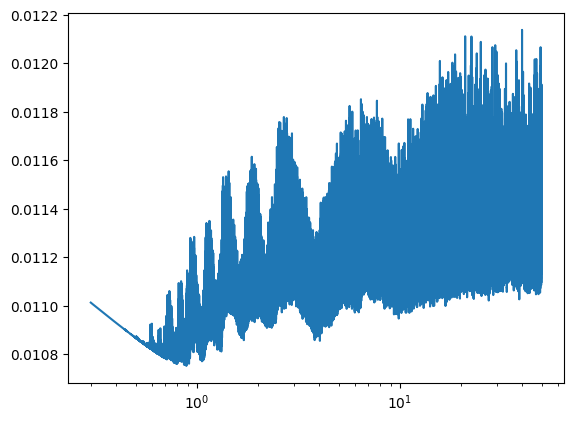

In [21]:
plt.figure()
plt.plot(10000 / wngrid, rprs)
plt.xscale("log")
plt.show()

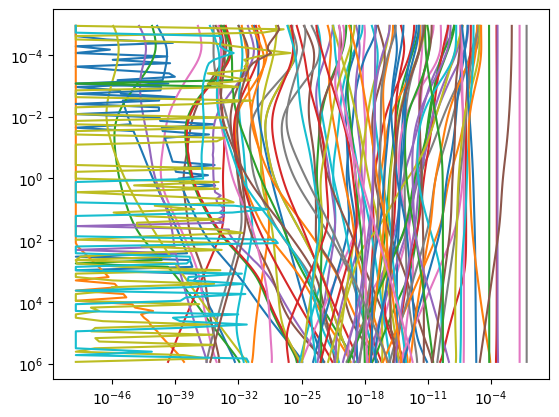

In [22]:
plt.figure()
plt.plot(tm_cpu.chemistry.mixProfile.T, tm_cpu.pressureProfile)
plt.gca().yaxis.set_inverted(True)
plt.yscale("log")
plt.xscale("log")
plt.show()